In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import os

In [2]:
df_train_featured = pd.read_csv('D:\\Credit Risk Modelling\\Data\\processed\\train_processed.csv')
df_test_featured = pd.read_csv('D:\\Credit Risk Modelling\\Data\\processed\\test_processed.csv')

In [3]:
df_train_featured['zipcode'] = df_train_featured['zipcode'].astype(str)
df_test_featured['zipcode'] = df_test_featured['zipcode'].astype(str)

In [4]:
df_test_featured.info()

<class 'pandas.DataFrame'>
RangeIndex: 12498 entries, 0 to 12497
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   cust_id                      12498 non-null  str    
 1   age                          12498 non-null  int64  
 2   gender                       12498 non-null  str    
 3   marital_status               12498 non-null  str    
 4   employment_status            12498 non-null  str    
 5   income                       12498 non-null  int64  
 6   number_of_dependants         12498 non-null  int64  
 7   residence_type               12498 non-null  str    
 8   years_at_current_address     12498 non-null  int64  
 9   city                         12498 non-null  str    
 10  state                        12498 non-null  str    
 11  zipcode                      12498 non-null  str    
 12  loan_id                      12498 non-null  str    
 13  loan_purpose               

### 1. Adding new features
- loan_to_income = loan_amount / income
- deliquent_ratio = delinquent_month / total_loan_month
- avg_dpd_per_deliquency = total_dpd / deliquent_month

In [5]:
df_train_featured['loan_to_income'] = round(df_train_featured['loan_amount'] / df_train_featured['income'], 2)
df_train_featured['deliquent_ratio'] = round(df_train_featured['delinquent_months'] / df_train_featured['total_loan_months'], 2)
df_train_featured['avg_dpd_per_deliquency'] = np.where(df_train_featured['delinquent_months'] > 0, (df_train_featured['total_dpd'] / df_train_featured['delinquent_months']).round(2), 0)

df_test_featured['loan_to_income'] = round(df_test_featured['loan_amount'] / df_test_featured['income'], 2)
df_test_featured['deliquent_ratio'] = round(df_test_featured['delinquent_months'] / df_test_featured['total_loan_months'], 2)
df_test_featured['avg_dpd_per_deliquency'] = np.where(df_test_featured['delinquent_months'] > 0, (df_test_featured['total_dpd'] / df_test_featured['delinquent_months']).round(2), 0)

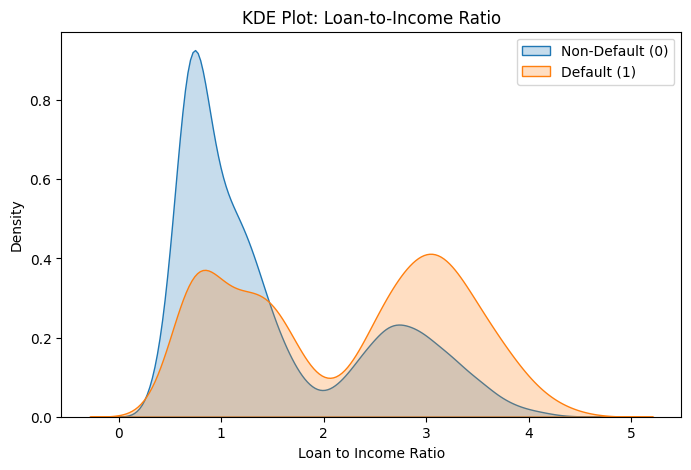

In [6]:
plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df_train_featured[df_train_featured['default'] == 0],
    x='loan_to_income',
    fill=True,
    label='Non-Default (0)',
    common_norm=False
)

sns.kdeplot(
    data=df_train_featured[df_train_featured['default'] == 1],
    x='loan_to_income',
    fill=True,
    label='Default (1)',
    common_norm=False
)

plt.title('KDE Plot: Loan-to-Income Ratio')
plt.xlabel('Loan to Income Ratio')
plt.legend()
plt.show()

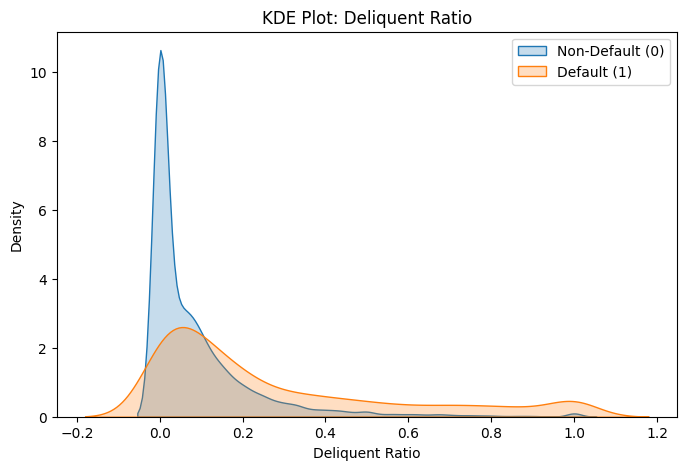

In [7]:
plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df_train_featured[df_train_featured['default'] == 0],
    x='deliquent_ratio',
    fill=True,
    label='Non-Default (0)',
    common_norm=False
)

sns.kdeplot(
    data=df_train_featured[df_train_featured['default'] == 1],
    x='deliquent_ratio',
    fill=True,
    label='Default (1)',
    common_norm=False
)

plt.title('KDE Plot: Deliquent Ratio')
plt.xlabel('Deliquent Ratio')
plt.legend()
plt.show()

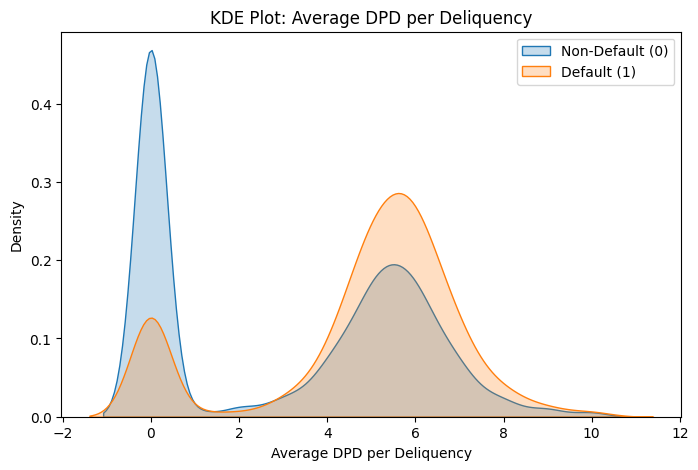

In [8]:
plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df_train_featured[df_train_featured['default'] == 0],
    x='avg_dpd_per_deliquency',
    fill=True,
    label='Non-Default (0)',
    common_norm=False
)

sns.kdeplot(
    data=df_train_featured[df_train_featured['default'] == 1],
    x='avg_dpd_per_deliquency',
    fill=True,
    label='Default (1)',
    common_norm=False
)

plt.title('KDE Plot: Average DPD per Deliquency')
plt.xlabel('Average DPD per Deliquency')
plt.legend()
plt.show()

- Higher loan to income ratio = Poor Repayment of loan
- Higher Deliquent ration = Low Repayment of loan
- Higher verage DPD per Deliquency = Low Repayment of loan

### 2. Feature Selection

In [9]:
df_train_featured.columns

Index(['cust_id', 'age', 'gender', 'marital_status', 'employment_status',
       'income', 'number_of_dependants', 'residence_type',
       'years_at_current_address', 'city', 'state', 'zipcode', 'loan_id',
       'loan_purpose', 'loan_type', 'sanction_amount', 'loan_amount',
       'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months',
       'principal_outstanding', 'bank_balance_at_application',
       'disbursal_date', 'installment_start_dt', 'number_of_open_accounts',
       'number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
       'total_dpd', 'enquiry_count', 'credit_utilization_ratio', 'default',
       'loan_to_income', 'deliquent_ratio', 'avg_dpd_per_deliquency'],
      dtype='str')

Columns to drop
- cust_id
- loan_id
- disbursal_date
- installment_start_dt
- loan_amount
- income
- total_loan_months
- delinquent_months
- total_dpd

In [10]:
df_train_featured = df_train_featured.drop(['cust_id','loan_id','disbursal_date','installment_start_dt','loan_amount','income',
                                           'delinquent_months','total_loan_months','total_dpd'], axis=1)
df_test_featured = df_test_featured.drop(['cust_id','loan_id','disbursal_date','installment_start_dt','loan_amount','income',
                                           'delinquent_months','total_loan_months','total_dpd'], axis=1)

In [11]:
df_train_featured.select_dtypes(['int64','float64']).columns

Index(['age', 'number_of_dependants', 'years_at_current_address',
       'sanction_amount', 'processing_fee', 'gst', 'net_disbursement',
       'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'number_of_open_accounts',
       'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'default', 'loan_to_income',
       'deliquent_ratio', 'avg_dpd_per_deliquency'],
      dtype='str')

### 3. Splitting the Dataset

In [12]:
X_train = df_train_featured.drop('default', axis=1)
y_train = df_train_featured['default']

X_test = df_test_featured.drop('default', axis=1)
y_test = df_test_featured['default']

### 4. Scaling 

In [13]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

col_to_scale = ['age', 'number_of_dependants', 'years_at_current_address',
       'sanction_amount', 'processing_fee', 'gst', 'net_disbursement',
       'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'number_of_open_accounts',
       'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'loan_to_income',
       'deliquent_ratio', 'avg_dpd_per_deliquency']
X_train_scaled = X_train.copy()
X_train_scaled[col_to_scale] = scaler.fit_transform(X_train[col_to_scale])

X_test_scaled = X_test.copy()
X_test_scaled[col_to_scale] = scaler.transform(X_test[col_to_scale])

In [14]:
X_train_scaled.head()

,age,gender,marital_status,employment_status,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode,...,loan_tenure_months,principal_outstanding,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,loan_to_income,deliquent_ratio,avg_dpd_per_deliquency
0,0.551694,F,Single,Salaried,-1.264738,Owned,-1.229979,Ahmedabad,Gujarat,380001,...,-0.152763,-0.355137,-0.403254,1.345872,1.230885,1.480630,0.533886,1.382587,-0.196603,0.759612
1,-1.071948,M,Single,Salaried,-1.264738,Owned,1.007643,Delhi,Delhi,110001,...,0.571666,-0.269667,-0.034623,0.450781,0.003960,-0.495705,1.658065,-0.488121,-0.428201,0.329068
2,1.059081,F,Single,Self-Employed,-1.264738,Mortgage,1.455168,Lucknow,Uttar Pradesh,226001,...,-0.555223,0.038041,-0.206355,-0.444310,0.003960,-0.495705,1.351471,-0.919823,0.382394,0.783722
3,0.348738,F,Single,Self-Employed,-0.613610,Owned,1.231405,Bangalore,Karnataka,560001,...,-0.394239,-0.960828,-0.832712,-1.339401,0.003960,-0.001621,-0.317764,-0.467564,-0.601900,-1.134780
4,-0.868993,F,Single,Salaried,-1.264738,Owned,1.231405,Jaipur,Rajasthan,302001,...,1.537571,-1.041561,-0.880200,-0.444310,-1.222964,-0.001621,-0.828755,0.293054,-0.022904,0.473731


In [15]:
X_train_scaled.info()

<class 'pandas.DataFrame'>
RangeIndex: 37487 entries, 0 to 37486
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          37487 non-null  float64
 1   gender                       37487 non-null  str    
 2   marital_status               37487 non-null  str    
 3   employment_status            37487 non-null  str    
 4   number_of_dependants         37487 non-null  float64
 5   residence_type               37487 non-null  str    
 6   years_at_current_address     37487 non-null  float64
 7   city                         37487 non-null  str    
 8   state                        37487 non-null  str    
 9   zipcode                      37487 non-null  str    
 10  loan_purpose                 37487 non-null  str    
 11  loan_type                    37487 non-null  str    
 12  sanction_amount              37487 non-null  float64
 13  processing_fee             

#### Calculating VIF to check Multi-Collinearity for Numerical Features

In [16]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(dataframe):
    vif_data = pd.DataFrame()
    vif_data['features'] = dataframe.columns
    vif_data['VIF'] = [variance_inflation_factor(dataframe.values, i) for i in range(dataframe.shape[1])]
    return vif_data

In [17]:
calculate_vif(X_train_scaled[col_to_scale])

d:\Credit Risk Modelling\venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,features,VIF
0,age,1.157714
1,number_of_dependants,1.069101
2,years_at_current_address,1.000291
3,sanction_amount,66.188758
4,processing_fee,inf
5,gst,inf
6,net_disbursement,inf
7,loan_tenure_months,1.745416
8,principal_outstanding,7.603354
9,bank_balance_at_application,5.099658


Due to high multi-collinearity, we are droping:
- sanction_amount
- processing_fee
- gst
- net_disbursement
- principal_outstanding

In [18]:
col_to_drop_vif = ['sanction_amount', 'processing_fee', 'gst', 'net_disbursement','principal_outstanding']

X_train_scaled_vif = X_train_scaled.drop(col_to_drop_vif,axis=1)
X_test_scaled_vif = X_test_scaled.drop(col_to_drop_vif,axis=1)

In [19]:
X_train_scaled_vif.head()

,age,gender,marital_status,employment_status,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode,...,loan_type,loan_tenure_months,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,loan_to_income,deliquent_ratio,avg_dpd_per_deliquency
0,0.551694,F,Single,Salaried,-1.264738,Owned,-1.229979,Ahmedabad,Gujarat,380001,...,Secured,-0.152763,-0.403254,1.345872,1.230885,1.480630,0.533886,1.382587,-0.196603,0.759612
1,-1.071948,M,Single,Salaried,-1.264738,Owned,1.007643,Delhi,Delhi,110001,...,Secured,0.571666,-0.034623,0.450781,0.003960,-0.495705,1.658065,-0.488121,-0.428201,0.329068
2,1.059081,F,Single,Self-Employed,-1.264738,Mortgage,1.455168,Lucknow,Uttar Pradesh,226001,...,Unsecured,-0.555223,-0.206355,-0.444310,0.003960,-0.495705,1.351471,-0.919823,0.382394,0.783722
3,0.348738,F,Single,Self-Employed,-0.613610,Owned,1.231405,Bangalore,Karnataka,560001,...,Secured,-0.394239,-0.832712,-1.339401,0.003960,-0.001621,-0.317764,-0.467564,-0.601900,-1.134780
4,-0.868993,F,Single,Salaried,-1.264738,Owned,1.231405,Jaipur,Rajasthan,302001,...,Secured,1.537571,-0.880200,-0.444310,-1.222964,-0.001621,-0.828755,0.293054,-0.022904,0.473731


In [20]:
numeric_col = X_train_scaled_vif.select_dtypes(['int64','float64']).columns
numeric_col

Index(['age', 'number_of_dependants', 'years_at_current_address',
       'loan_tenure_months', 'bank_balance_at_application',
       'number_of_open_accounts', 'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'loan_to_income', 'deliquent_ratio',
       'avg_dpd_per_deliquency'],
      dtype='str')

In [21]:
vif_data = calculate_vif(X_train_scaled_vif[numeric_col])
vif_data

,features,VIF
0,age,1.122579
1,number_of_dependants,1.069025
2,years_at_current_address,1.000180
3,loan_tenure_months,1.705549
4,bank_balance_at_application,1.003187
5,number_of_open_accounts,1.563755
6,number_of_closed_accounts,1.000258
7,enquiry_count,1.413603
8,credit_utilization_ratio,1.000290
9,loan_to_income,1.758336


In [22]:
selected_features_vif = vif_data['features'].values
selected_features_vif

<StringArray>
[                        'age',        'number_of_dependants',
    'years_at_current_address',          'loan_tenure_months',
 'bank_balance_at_application',     'number_of_open_accounts',
   'number_of_closed_accounts',               'enquiry_count',
    'credit_utilization_ratio',              'loan_to_income',
             'deliquent_ratio',      'avg_dpd_per_deliquency']
Length: 12, dtype: str

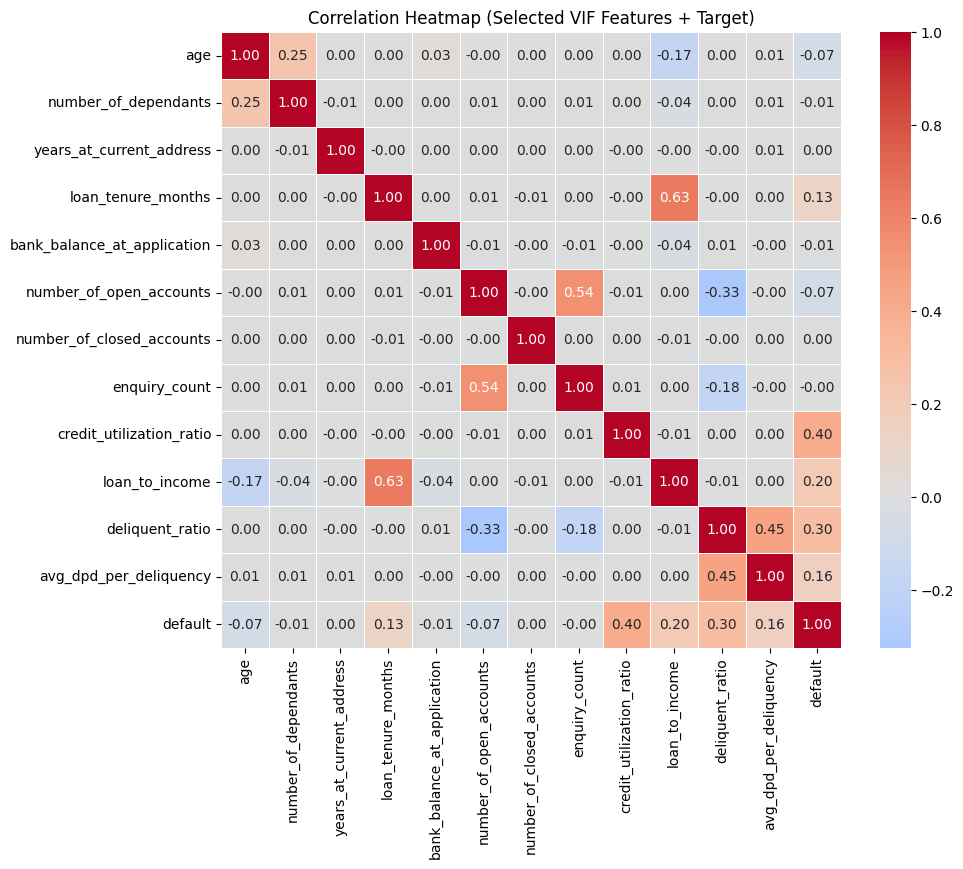

In [23]:
# Create dataframe with selected features
heatmap_df = X_train_scaled_vif[selected_features_vif].copy()

# Add target variable
heatmap_df['default'] = y_train.values

# Compute correlation matrix
corr_matrix = heatmap_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap (Selected VIF Features + Target)")
plt.show()

#### Calculating Weight of Evidence(WOE) and Information Value(IV) for Categorical features

In [24]:
Categorical_columns = X_train_scaled_vif.select_dtypes(['object']).columns
Categorical_columns

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_15672\3708682136.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  Categorical_columns = X_train_scaled_vif.select_dtypes(['object']).columns


Index(['gender', 'marital_status', 'employment_status', 'residence_type',
       'city', 'state', 'zipcode', 'loan_purpose', 'loan_type'],
      dtype='str')

In [25]:
for col in X_train_scaled_vif.columns:
    try:
        pd.to_numeric(X_train_scaled_vif[col])
    except Exception as e:
        print("Problem column:", col)
        print(X_train_scaled_vif[col].unique()[:10])
        break

Problem column: gender
<StringArray>
['F', 'M']
Length: 2, dtype: str


In [26]:
def calculate_iv_woe(dataframe, feature, target):
    
    iv_dict = {}
    
        
    grouped = dataframe.groupby(feature)[target].agg(['count','sum'])
    grouped = grouped.rename(columns={'count': 'Total', 'sum': 'Success'})
    grouped['Failure'] = grouped['Total'] - grouped['Success']

    grouped['Success Rate'] = grouped['Success'] / grouped['Success'].sum()
    grouped['Failure Rate'] = grouped['Failure'] / grouped['Failure'].sum()

    grouped['WOE'] = np.log(grouped['Success Rate'] / grouped['Failure Rate'])
    grouped['IV'] = (grouped['Success Rate'] - grouped['Failure Rate']) * grouped['WOE']
    grouped['WOE'] = grouped['WOE'].replace([np.inf, -np.inf], 0)
    grouped['IV'] = grouped['IV'].replace([np.inf, -np.inf], 0)
        
    total_iv = grouped['IV'].sum()
        
        
    return grouped, total_iv

In [27]:
from pandas.api.types import is_numeric_dtype

iv_values = {}
for col in X_train_scaled_vif.columns:

    if is_numeric_dtype(X_train_scaled_vif[col]):

        # numeric column
        binned = pd.cut(X_train_scaled_vif[col], bins=10, labels=False)

        grouped, total_iv = calculate_iv_woe(
            pd.concat([binned, y_train], axis=1),
            col,
            'default'
        )

    else:
        # categorical column (like gender)
        grouped, total_iv = calculate_iv_woe(
            pd.concat([X_train_scaled_vif[[col]], y_train], axis=1),
            col,
            'default'
        )

    iv_values[col] = total_iv

In [28]:
iv_df = pd.DataFrame(list(iv_values.items()), columns=['Feature', 'IV'])
iv_df.sort_values(by='IV', ascending=False, inplace=True)
iv_df

,Feature,IV
17,credit_utilization_ratio,2.422823
19,deliquent_ratio,0.678183
18,loan_to_income,0.491566
20,avg_dpd_per_deliquency,0.421180
10,loan_purpose,0.393775
5,residence_type,0.259402
12,loan_tenure_months,0.234506
11,loan_type,0.173047
0,age,0.075927
14,number_of_open_accounts,0.073243


In [29]:
selected_feature = iv_df[iv_df['IV'] > 0.02]['Feature'].tolist()
selected_feature

['credit_utilization_ratio',
 'deliquent_ratio',
 'loan_to_income',
 'avg_dpd_per_deliquency',
 'loan_purpose',
 'residence_type',
 'loan_tenure_months',
 'loan_type',
 'age',
 'number_of_open_accounts']

In [30]:
X_train_scaled_vif_selected = X_train_scaled_vif[selected_feature]
X_test_scaled_vif_selected = X_test_scaled_vif[selected_feature]

In [31]:
print(X_train_scaled_vif_selected.shape)
print(y_train.shape)

(37487, 10)
(37487,)


In [32]:
X_train_scaled_vif_selected_encoded = pd.get_dummies(X_train_scaled_vif_selected, drop_first=True)
X_test_scaled_vif_selected_encoded = pd.get_dummies(X_test_scaled_vif_selected, drop_first=True)

In [33]:
X_train_scaled_vif_selected_encoded.columns

Index(['credit_utilization_ratio', 'deliquent_ratio', 'loan_to_income',
       'avg_dpd_per_deliquency', 'loan_tenure_months', 'age',
       'number_of_open_accounts', 'loan_purpose_Education',
       'loan_purpose_Home', 'loan_purpose_Personal', 'residence_type_Owned',
       'residence_type_Rented', 'loan_type_Unsecured'],
      dtype='str')

In [34]:
X_train_scaled_vif_selected_encoded.head()

,credit_utilization_ratio,deliquent_ratio,loan_to_income,avg_dpd_per_deliquency,loan_tenure_months,age,number_of_open_accounts,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal,residence_type_Owned,residence_type_Rented,loan_type_Unsecured
0,0.533886,-0.196603,1.382587,0.759612,-0.152763,0.551694,1.345872,False,True,False,True,False,False
1,1.658065,-0.428201,-0.488121,0.329068,0.571666,-1.071948,0.450781,False,False,False,True,False,False
2,1.351471,0.382394,-0.919823,0.783722,-0.555223,1.059081,-0.444310,False,False,True,False,False,True
3,-0.317764,-0.601900,-0.467564,-1.134780,-0.394239,0.348738,-1.339401,False,False,False,True,False,False
4,-0.828755,-0.022904,0.293054,0.473731,1.537571,-0.868993,-0.444310,True,False,False,True,False,False


In [35]:
X_test_scaled_vif_selected_encoded.head()

,credit_utilization_ratio,deliquent_ratio,loan_to_income,avg_dpd_per_deliquency,loan_tenure_months,age,number_of_open_accounts,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal,residence_type_Owned,residence_type_Rented,loan_type_Unsecured
0,-1.067217,-0.370302,-0.159205,1.965134,0.652158,-0.361605,-0.444310,True,False,False,True,False,False
1,1.419603,-0.601900,1.732060,-1.134780,1.054619,-0.666038,1.345872,False,True,False,True,False,False
2,0.976744,-0.601900,1.495652,-1.134780,1.054619,-1.173425,1.345872,False,True,False,True,False,False
3,1.589933,-0.601900,-0.467564,-1.134780,-0.796699,-1.173425,0.450781,False,False,False,False,True,False
4,0.329490,0.150795,-0.549793,0.673503,0.008222,1.262037,1.345872,False,False,False,True,False,False


In [37]:
import joblib
joblib.dump(scaler, "D:\\Credit Risk Modelling\\models\\scaler.joblib")

['D:\\Credit Risk Modelling\\models\\scaler.joblib']

In [36]:
os.makedirs('D:\\Credit Risk Modelling\\Data\\featured', exist_ok=True)
X_train_scaled_vif_selected_encoded.to_csv('D:\\Credit Risk Modelling\\Data\\featured\\train_featured.csv', index=False)
X_test_scaled_vif_selected_encoded.to_csv('D:\\Credit Risk Modelling\\Data\\featured\\test_featured.csv', index=False)
y_train.to_csv('D:\\Credit Risk Modelling\\Data\\featured\\y_train.csv', index=False)
y_test.to_csv('D:\\Credit Risk Modelling\\Data\\featured\\y_test.csv', index=False)